In [14]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.colors as mcolors
import pickle
import matplotlib.pyplot as plt
import sys


sys.path.append("../") 
import WRFDomainLib
# Example usage
def plasma_white(vmin=-1, vmax=6):
    # Start with inferno
    inferno = cm.get_cmap("plasma_r", 256)
    # Replace the first color with white
    colors = inferno(np.linspace(0, 1, 256))
    colors[0] = np.array([1, 1, 1, 1])  # RGBA for white
    return mcolors.LinearSegmentedColormap.from_list("plasma_white", colors)
cmap = plasma_white()#inferno_white()

mpl.rcParams['hatch.linewidth'] = 0.1
mpl.rcParams['patch.edgecolor']='none'
WPSFile = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/plotting_files/namelist.wps.txt'
wpsproj, latlonproj, corner_lat_full, corner_lon_full, length_x, length_y = WRFDomainLib.calc_wps_domain_info(WPSFile)

seasons = [ 'SON', 'JJA', 'MAM','DJF']


/tmp/amh001/1236/ipykernel_1466/893277618.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inferno = cm.get_cmap("plasma_r", 256)


In [15]:
at=0.1;bt=0.9

# Define grid shape (rows, columns)
nrows = len(seasons)
ncols = 4
sublist=['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o','p', 'q', 'r', 's', 't', 'u']
# Reshape and transpose
subpanel = np.array(sublist[:nrows * ncols]).reshape(nrows, ncols).T.flatten().tolist()

label={"t": r" $\Delta$T$_{95p}$ ($^\circ$C) ", "tmin":r"$\Delta$T$_{5p}$ ($^\circ$C)", "pr": '$\Delta_r$Pr$_{95p}$ (%)', "wind": '$\Delta_r$Wspd$_{95p}$ (%)'}
var_cmaps = {"t":plasma_white(0,8),"tmin":plasma_white(0,8), "pr":"BrBG", "wind":"PuOr"}
vlims = {"tmin":(0,8),"t":(0,8), "pr":(-60,60), "wind":(-20,20)}

# Hatching where pval < 0.1
dense_dots = "." * 3  # repeat the dot
hatch_pattern = dense_dots # + " " + dense_dots  # optional spacing


/tmp/amh001/1236/ipykernel_1466/893277618.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inferno = cm.get_cmap("plasma_r", 256)


In [16]:
def getseasons(var, period, perc, rel, med):
    
    if med=='_med':
        p0 = 75 if var == 'pr' else 50
    else:
        p0=''
    season_data = {}
    for s in seasons:
        filepath=f'/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/{var}_{s}_{period}_boots_years_1000_perc_{perc}{rel}{med}{p0}.pkl'
        
        print('filepath', filepath)
        # ---- Load results ----
        with open(filepath, "rb") as f:
            data = pickle.load(f)
        perc_delta=data['perc_delta']
        p_val = data["p_value"]
        print(s,perc_delta.mean())
        season_data[s] = (data[f"perc_delta"], data[f"p_value"])
    return season_data

In [17]:
#med is for the percentil minus median results

In [18]:
seasons = [ 'SON', 'JJA', 'MAM','DJF']
#seasons = ["DJF", "MAM", "JJA", "SON"]
var='T2'; period='rcp45'; perc=95; rel=''; med=''
season_data_t = getseasons(var, period, perc, rel, med)
var='pr'; rel='_rel'
season_data_pr = getseasons(var, period, perc, rel, med)
var='wspd'; rel='_rel'
season_data_wind = getseasons(var, period, perc, rel, med)
var='T2';  perc=5; rel=''
season_data_tmin = getseasons(var, period, perc, rel, med)


filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_SON_rcp45_boots_years_1000_perc_95.pkl
SON 2.3495585280164084
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_JJA_rcp45_boots_years_1000_perc_95.pkl
JJA 2.5132441465646247
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_MAM_rcp45_boots_years_1000_perc_95.pkl
MAM 1.177123671432778
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_DJF_rcp45_boots_years_1000_perc_95.pkl
DJF 1.6785756049375182
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/pr_SON_rcp45_boots_years_1000_perc_95_rel.pkl
SON nan
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/pr_JJA_rcp45_boots_years_1000_perc_95_rel.pkl
JJA nan
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/pr_MAM_rcp45_boots_years_1000_perc_95_rel.pkl
MAM nan
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/pr_DJF_rcp45_boots_years_1000_perc_95_rel.pkl
DJF nan
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/wsp

In [19]:
#load lats and lons like this for now, but need to add to extremes
filepath='/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/MEANS/seasonal_deltas_and_pvals_pr_rcp45_d03.npz'
data = np.load(filepath)
lat= data ['lat']
lon=data['lon']

In [20]:



#mpl.rcParams['hatch.color'] = 'gray'
def plotseasons(j, count, season_data, axes, seasons, nmodels, var):
#j=0
#count=0
    vmin=vlims[var][0];vmax=vlims[var][1]
    #print(vmin, vmax)
    for i, season in enumerate(seasons):
        ax = axes[i, j] if nmodels > 1 else axes[i]
        field = season_data[season][0]
        pval  = season_data[season][1]
        #print('D3 pvals', np.amax(pval), np.amin(pval))
        # Main colormap
        #print(vmin, vmax)
        mesh = ax.pcolormesh(
            lon, lat, field,
            cmap=var_cmaps[var], vmin=vmin,vmax=vmax,
            transform=ccrs.PlateCarree()    )
        #meshes.append(mesh)
    
        
        cs = ax.contourf(
            lon, lat, pval,
            levels=[0.1, 1],
            colors="none", 
            hatches=[hatch_pattern],  # pass as a list
            transform=ccrs.PlateCarree()
        )
        coastline = cf.COASTLINE.with_scale('10m')
        ax.add_feature(coastline, linewidth=0.1, edgecolor='black')

    
        ax.text(at, bt, subpanel[count], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
        if j==0:
            ax.text(-0.18, 0.6, season, transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
        #ax.text(.6, 1.1,'D3' , transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
        ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())
        
        count+=1

    if i == len(seasons) - 1:  # After last row in the column
        # Get position of the bottom axis in the column
        bbox = ax.get_position()
        # Create a new axis below it for the colorbar
        cbar_ax = fig.add_axes([
            bbox.x0, bbox.y0 - 0.03,  # slightly below the bottom subplot
            bbox.width, 0.015         # same width, small height
        ])
        cbar = fig.colorbar(mesh, cax=cbar_ax, extend='both', orientation="horizontal")
        cbar.set_label(label[var], fontsize=10)
        cbar.set_ticks([vmin,(vmax-abs(vmin))/2,vmax])
    return count

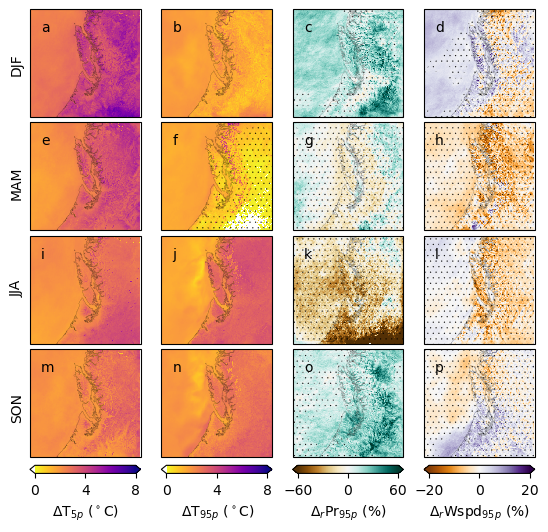

In [21]:

seasons = ["DJF", "MAM", "JJA", "SON"]
fig, axes = plt.subplots(
        nrows=len(seasons), ncols=ncols,
        figsize=(6.7,5.4),
        subplot_kw={"projection": wpsproj}
    )
fig.subplots_adjust(bottom=0.05, hspace=0.05, wspace=0.05)

count=0
count=plotseasons(0, count, season_data_tmin, axes, seasons, ncols, 'tmin')
count=plotseasons(1, count, season_data_t, axes, seasons, ncols, 't')
count=plotseasons(2, count, season_data_pr, axes, seasons, ncols, 'pr')
count=plotseasons(3, count, season_data_wind, axes, seasons, ncols, 'wind')
#plt.show()
plt.savefig('../Figures/Extremes_RCP45.png', format='png', bbox_inches='tight',transparent=False,dpi=500)
#plt.close(fig)

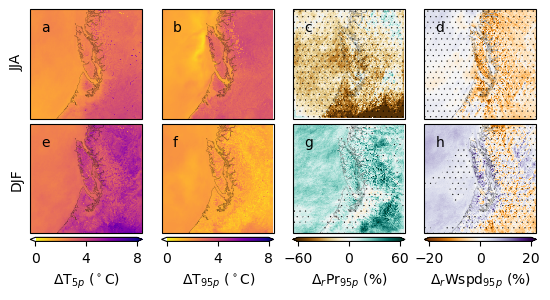

In [22]:
seasons = ['JJA', 'DJF']
#seasons = [ 'SON', 'JJA', 'MAM','DJF']

nrows = len(seasons)
ncols = 4
sublist=['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o','p', 'q', 'r', 's', 't', 'u']
# Reshape and transpose
subpanel = np.array(sublist[:nrows * ncols]).reshape(nrows, ncols).T.flatten().tolist()

#var_cmaps = {"t":'RdBu_r',"tmin":'RdBu_r', "pr":"BrBG", "wind":"PuOr"}
#vlims = {"tmin":(-4,4),"t":(-4,4), "pr":(-80,80), "wind":(-20,20)}
nmodels=4;
# Hatching where pval < 0.1
#label={"t": r"$\Delta$ T$_{95p-50p}$ ($^\circ$C) ", "tmin":r"$\Delta$ T$_{50p-5p}$ ($^\circ$C)", "pr": '$\Delta$ P$_{ 95p-50p}$ (%)', "wind": '$\Delta$ Wspd$_95p-50p$ (%)'}
#label={"t": r" $\Delta$ T$_{ut}$ ($^\circ$C) ", "tmin":r"$\Delta$ T$_{LT}$ ($^\circ$C)", "pr": '$\Delta$ P$_{UT}$ (%)', "wind": '$\Delta$ Wspd$_{UT}$ (%)'}
fig, axes = plt.subplots(
        nrows=len(seasons), ncols=nmodels,
        figsize=(6.7,2.7),
        subplot_kw={"projection": wpsproj}
    )
fig.subplots_adjust(bottom=0.05, hspace=0.05, wspace=0.05)

count=0
count=plotseasons(0, count, season_data_tmin, axes, seasons, nmodels, 'tmin')
count=plotseasons(1, count, season_data_t, axes, seasons, nmodels, 't')
count=plotseasons(2, count, season_data_pr, axes, seasons, nmodels, 'pr')
count=plotseasons(3, count, season_data_wind, axes, seasons, nmodels, 'wind')
plt.savefig('../Figures/Extremes_RCP45_WS.png', format='png', bbox_inches='tight',transparent=False,dpi=500)
plt.show()
plt.close(fig)

In [23]:
#seasons = [ 'SON', 'JJA', 'MAM','DJF']
seasons = ["DJF", "MAM", "JJA", "SON"]

var='T2'; period='rcp45'; perc=95; rel=''; med='_med'
season_data_t = getseasons(var, period, perc, rel, med)
var='pr'; rel='_rel'
season_data_pr = getseasons(var, period, perc, rel, '_med75')
var='wspd'; rel='_rel'
season_data_wind = getseasons(var, period, perc, rel, med)
var='T2';  perc=5; rel=''
season_data_tmin = getseasons(var, period, perc, rel, med)


filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_DJF_rcp45_boots_years_1000_perc_95_med50.pkl
DJF -0.7112492235989042
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_MAM_rcp45_boots_years_1000_perc_95_med50.pkl
MAM -0.8985923557740668
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_JJA_rcp45_boots_years_1000_perc_95_med50.pkl
JJA 0.11100098698086193
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/T2_SON_rcp45_boots_years_1000_perc_95_med50.pkl
SON -0.0707709877127188
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/pr_DJF_rcp45_boots_years_1000_perc_95_rel_med75.pkl
DJF 12.206199489651567
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/pr_MAM_rcp45_boots_years_1000_perc_95_rel_med75.pkl
MAM 4.065849777507979
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/pr_JJA_rcp45_boots_years_1000_perc_95_rel_med75.pkl
JJA -22.58428831683875
filepath /gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/Extremes/pr_SON_rcp45_boots_years

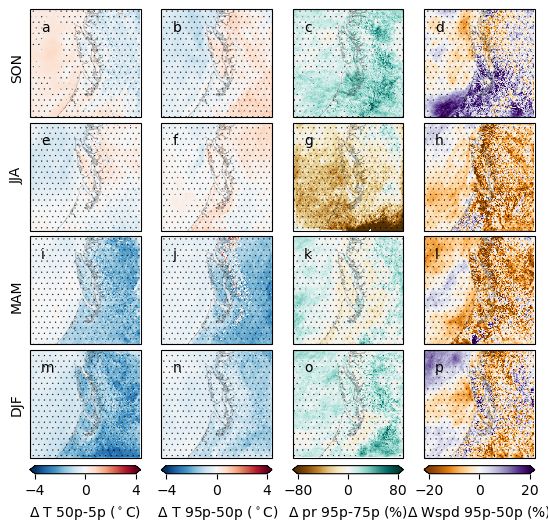

In [24]:
seasons = [ 'SON', 'JJA', 'MAM','DJF']
nrows = len(seasons)
subpanel = np.array(sublist[:nrows * ncols]).reshape(nrows, ncols).T.flatten().tolist()

var_cmaps = {"t":'RdBu_r',"tmin":'RdBu_r', "pr":"BrBG", "wind":"PuOr"}
vlims = {"tmin":(-4,4),"t":(-4,4), "pr":(-80,80), "wind":(-20,20)}
nmodels=4;
# Hatching where pval < 0.1
label={"t": r" $\Delta$ T 95p-50p ($^\circ$C) ", "tmin":r"$\Delta$ T 50p-5p ($^\circ$C)", "pr": '$\Delta$ pr 95p-75p (%)', "wind": '$\Delta$ Wspd 95p-50p (%)'}
fig, axes = plt.subplots(
        nrows=len(seasons), ncols=nmodels,
        figsize=(6.7,5.4),
        subplot_kw={"projection": wpsproj}
    )
fig.subplots_adjust(bottom=0.05, hspace=0.05, wspace=0.05)

count=0
count=plotseasons(0, count, season_data_tmin, axes, seasons, nmodels, 'tmin')
count=plotseasons(1, count, season_data_t, axes, seasons, nmodels, 't')
count=plotseasons(2, count, season_data_pr, axes, seasons, nmodels, 'pr')
count=plotseasons(3, count, season_data_wind, axes, seasons, nmodels, 'wind')
plt.savefig('../Figures/Extremes_RCP45_median.png', format='png', bbox_inches='tight',transparent=False,dpi=500)
plt.show()
plt.close(fig)

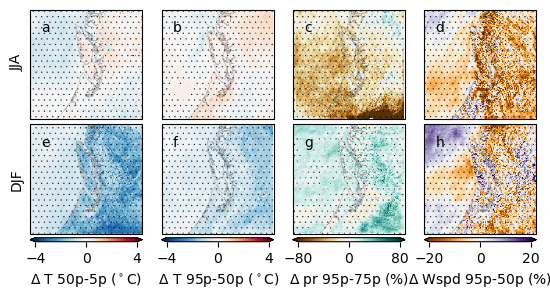

In [25]:
seasons = ['JJA', 'DJF']
nrows = len(seasons)
ncols = 4
sublist=['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o','p', 'q', 'r', 's', 't', 'u']
# Reshape and transpose
subpanel = np.array(sublist[:nrows * ncols]).reshape(nrows, ncols).T.flatten().tolist()

var_cmaps = {"t":'RdBu_r',"tmin":'RdBu_r', "pr":"BrBG", "wind":"PuOr"}
vlims = {"tmin":(-4,4),"t":(-4,4), "pr":(-80,80), "wind":(-20,20)}
nmodels=4;
# Hatching where pval < 0.1

#label={"t": r" $\Delta$ T$_{ut}$ ($^\circ$C) ", "tmin":r"$\Delta$ T$_{LT}$ ($^\circ$C)", "pr": '$\Delta$ P$_{UT}$ (%)', "wind": '$\Delta$ Wspd$_{UT}$ (%)'}
fig, axes = plt.subplots(
        nrows=len(seasons), ncols=nmodels,
        figsize=(6.7,2.7),
        subplot_kw={"projection": wpsproj}
    )
fig.subplots_adjust(bottom=0.05, hspace=0.05, wspace=0.05)

count=0
count=plotseasons(0, count, season_data_tmin, axes, seasons, nmodels, 'tmin')
count=plotseasons(1, count, season_data_t, axes, seasons, nmodels, 't')
count=plotseasons(2, count, season_data_pr, axes, seasons, nmodels, 'pr')
count=plotseasons(3, count, season_data_wind, axes, seasons, nmodels, 'wind')
plt.savefig('../Figures/Extremes_RCP45_median_WS.png', format='png', bbox_inches='tight',transparent=False,dpi=500)
plt.show()
plt.close(fig)

In [26]:
plt.close(fig)
